In [1]:
!pip install uv

In [2]:
!uv pip install kagglehub[pandas-datasets]

Using Python 3.13.8 environment at: c:\Users\SamBa\OneDrive\Desktop\Data Engineering\Udemy lessons\.venv
Checked 1 package in 5ms


In [3]:
import sys 
print(sys.executable)

c:\Users\SamBa\miniconda3\python.exe


In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("imoore/age-dataset")

print("Path to dataset files: ", path)

Path to dataset files:  C:\Users\SamBa\.cache\kagglehub\datasets\imoore\age-dataset\versions\1


In [5]:
import os

print(os.listdir(path))

path_csv = os.path.join(path, "AgeDataset-V1.csv")

['AgeDataset-V1.csv']


In [6]:
import pandas as pd

df = pd.read_csv(path_csv)
df.head()

,Id,Name,Short description,Gender,Country,Occupation,Birth year,Death year,Manner of death,Age of death
0,Q23,George Washington,1st president of the United States (1732–1799),Male,United States of America; Kingdom of Great Bri...,Politician,1732,1799.0,natural causes,67.0
1,Q42,Douglas Adams,English writer and humorist,Male,United Kingdom,Artist,1952,2001.0,natural causes,49.0
2,Q91,Abraham Lincoln,16th president of the United States (1809-1865),Male,United States of America,Politician,1809,1865.0,homicide,56.0
3,Q254,Wolfgang Amadeus Mozart,Austrian composer of the Classical period,Male,Archduchy of Austria; Archbishopric of Salzburg,Artist,1756,1791.0,NaN,35.0
4,Q255,Ludwig van Beethoven,German classical and romantic composer,Male,Holy Roman Empire; Austrian Empire,Artist,1770,1827.0,NaN,57.0


In [7]:
# from pathlib import Path

# new_path = Path("assets/people.csv")

# df.to_csv(new_path, index=False)

Basic EDA (Exploratory data Analysis)

In [8]:
df

,Id,Name,Short description,Gender,Country,Occupation,Birth year,Death year,Manner of death,Age of death
0,Q23,George Washington,1st president of the United States (1732–1799),Male,United States of America; Kingdom of Great Bri...,Politician,1732,1799.0,natural causes,67.0
1,Q42,Douglas Adams,English writer and humorist,Male,United Kingdom,Artist,1952,2001.0,natural causes,49.0
2,Q91,Abraham Lincoln,16th president of the United States (1809-1865),Male,United States of America,Politician,1809,1865.0,homicide,56.0
3,Q254,Wolfgang Amadeus Mozart,Austrian composer of the Classical period,Male,Archduchy of Austria; Archbishopric of Salzburg,Artist,1756,1791.0,NaN,35.0
4,Q255,Ludwig van Beethoven,German classical and romantic composer,Male,Holy Roman Empire; Austrian Empire,Artist,1770,1827.0,NaN,57.0
...,...,...,...,...,...,...,...,...,...,...
1223004,Q77247326,Marie-Fortunée Besson,Frans model (1907-1996),NaN,France,Tailor; model,1907,1996.0,NaN,89.0
1223005,Q77249504,Ron Thorsen,xugador de baloncestu canadianu (1948–2004),NaN,Canada; United States of America,Athlete,1948,2004.0,NaN,56.0
1223006,Q77249818,Diether Todenhagen,German navy officer and world war II U-boat co...,NaN,Germany,Military personnel,1920,1944.0,NaN,24.0
1223007,Q77253909,Reginald Oswald Pearson,"English artist, working in stained glass, prin...",Male,United Kingdom,Artist,1887,1915.0,NaN,28.0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1223009 entries, 0 to 1223008
Data columns (total 10 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   Id                 1223009 non-null  object 
 1   Name               1223009 non-null  object 
 2   Short description  1155109 non-null  object 
 3   Gender             1089363 non-null  object 
 4   Country            887500 non-null   object 
 5   Occupation         1016095 non-null  object 
 6   Birth year         1223009 non-null  int64  
 7   Death year         1223008 non-null  float64
 8   Manner of death    53603 non-null    object 
 9   Age of death       1223008 non-null  float64
dtypes: float64(2), int64(1), object(7)
memory usage: 93.3+ MB


In [10]:
df.isna().sum()

Id                         0
Name                       0
Short description      67900
Gender                133646
Country               335509
Occupation            206914
Birth year                 0
Death year                 1
Manner of death      1169406
Age of death               1
dtype: int64

In [11]:
df.isna().sum() / len(df) * 100

Id                    0.000000
Name                  0.000000
Short description     5.551881
Gender               10.927638
Country              27.433077
Occupation           16.918436
Birth year            0.000000
Death year            0.000082
Manner of death      95.617121
Age of death          0.000082
dtype: float64

In [12]:
df.shape

(1223009, 10)

In [13]:
df.describe()

,Birth year,Death year,Age of death
count,1.223009e+06,1.223008e+06,1.223008e+06
mean,1.844972e+03,1.914246e+03,6.927406e+01
std,1.479390e+02,1.516898e+02,1.662938e+01
min,-2.700000e+03,-2.659000e+03,0.000000e+00
25%,1.828000e+03,1.895000e+03,6.000000e+01
50%,1.887000e+03,1.955000e+03,7.200000e+01
75%,1.918000e+03,1.994000e+03,8.100000e+01
max,2.016000e+03,2.021000e+03,1.690000e+02


In [14]:
# df.value_counts("Country").plot(kind="bar")

In [15]:
df["Country"].unique()

array(['United States of America; Kingdom of Great Britain',
       'United Kingdom', 'United States of America', ...,
       'El Salvador; Prussia; German Empire; North German Confederation',
       'Syria; State of Syria; Syrian Republic',
       'El Salvador; British Empire'], shape=(5962,), dtype=object)

In [16]:
df["Country"].nunique()

5961

In [17]:
df.value_counts("Occupation")

Occupation
Artist                      281512
Politician                  195390
Athlete                     110943
Researcher                   90709
Military personnel           52911
                             ...  
Zookeeper; biologist             1
Zookeeper; lion taming           1
Zookeeper; primatologist         1
École polytechnique              1
Winegrower; magistrate           1
Name: count, Length: 9313, dtype: int64

In [18]:
df.groupby("Occupation")["Age of death"].mean().sort_values(ascending=False)

Occupation
Farmer; lecturer         121.0
Deacon; preacher          99.0
Warrior; noble            99.0
Nurse; weaver; sailor     99.0
Studienrat; lecturer      99.0
                         ...  
Lehnsmann                 13.0
Basij                     13.0
Servant of god            12.0
Pioneers-heroes           11.0
Miner; master builder     11.0
Name: Age of death, Length: 9313, dtype: float64

Age of death by occputaion

In [19]:
df.groupby("Occupation")["Age of death"].describe()

,count,mean,std,min,25%,50%,75%,max
Occupation,,,,,,,,
1859,1.0,47.000000,NaN,47.0,47.0,47.0,47.0,47.0
Abbess,36.0,60.694444,16.924740,24.0,49.0,63.0,73.0,90.0
Abbess; business executive,1.0,86.000000,NaN,86.0,86.0,86.0,86.0,86.0
Abbess; christians jehovah’s witnesses,1.0,81.000000,NaN,81.0,81.0,81.0,81.0,81.0
Abbé,6.0,69.666667,16.070677,41.0,66.0,72.5,79.0,87.0
...,...,...,...,...,...,...,...,...
Zoology,1.0,44.000000,NaN,44.0,44.0,44.0,44.0,44.0
Zoology; marine biology; biologist,1.0,73.000000,NaN,73.0,73.0,73.0,73.0,73.0
École polytechnique,1.0,72.000000,NaN,72.0,72.0,72.0,72.0,72.0


In [20]:
df["Occupation"].value_counts() 

Occupation
Artist                                281512
Politician                            195390
Athlete                               110943
Researcher                             90709
Military personnel                     52911
                                       ...  
Dispatcher; drafter                        1
Tour operator                              1
Chief executive officer; president         1
Mayor; city attorney                       1
Nurse; civil servant; matron               1
Name: count, Length: 9313, dtype: int64

In [21]:
occup_counts = df["Occupation"].value_counts()

In [22]:
occup_counts[occup_counts >= 1000].index

Index(['Artist', 'Politician', 'Athlete', 'Researcher', 'Military personnel',
       'Religious figure', 'Businessperson', 'Architect', 'Journalist',
       'Teacher', 'Physician', 'Engineer', 'Judge', 'Lawyer', 'Jurist',
       'Aristocrat', 'Entrepreneur', 'Philosopher', 'Translator', 'Publisher',
       'Librarian', 'Author', 'Surgeon', 'Merchant', 'Novelist', 'Rower',
       'Astronomer', 'Pianist', 'Psychologist', 'Pastor', 'Minister', 'Farmer',
       'Inventor', 'Psychiatrist', 'Rabbi', 'Explorer', 'Fencer',
       'Police officer', 'Trade unionist', 'Official'],
      dtype='object', name='Occupation')

In [23]:
occupations_more_than_100 = occup_counts[occup_counts >= 1000].index

In [24]:
df = df[df["Occupation"].isin(occupations_more_than_100)]

In [25]:
age_by_occup = df.groupby("Occupation")["Age of death"].mean()
age_by_occup

Occupation
Architect             72.085306
Aristocrat            53.006540
Artist                69.725145
Astronomer            71.152301
Athlete               68.772460
Author                70.094754
Businessperson        74.153054
Engineer              72.156611
Entrepreneur          73.222146
Explorer              61.799302
Farmer                71.240991
Fencer                72.496454
Inventor              73.129545
Journalist            69.591239
Judge                 74.004850
Jurist                69.488372
Lawyer                71.231208
Librarian             73.437335
Merchant              68.316125
Military personnel    63.820056
Minister              69.176471
Novelist              71.452949
Official              71.659000
Pastor                68.870213
Philosopher           71.037957
Physician             70.683996
Pianist               71.754000
Police officer        64.403013
Politician            70.541558
Psychiatrist          73.231385
Psychologist          76.3963

<Axes: xlabel='Occupation'>

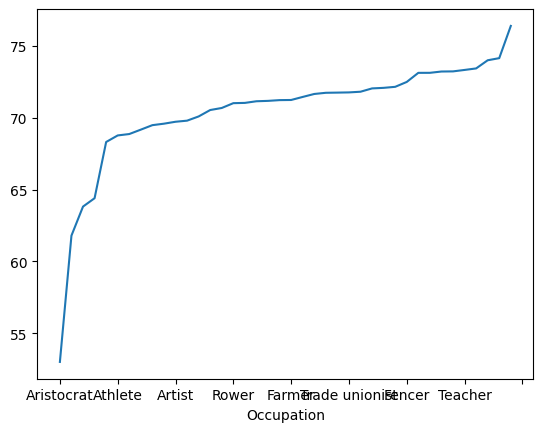

In [26]:
age_by_occup.sort_values(ascending=True).plot()

Suicide

In [27]:
df.columns

Index(['Id', 'Name', 'Short description', 'Gender', 'Country', 'Occupation',
       'Birth year', 'Death year', 'Manner of death', 'Age of death'],
      dtype='object')

In [28]:
df["Manner of death"].value_counts()

Manner of death
natural causes        29724
suicide                4651
accident               4220
homicide               3277
capital punishment     1816
                      ...  
rebellion                 1
Holocaust victim          1
unknown                   1
war; suicide              1
White Terror              1
Name: count, Length: 166, dtype: int64

In [29]:
df_suicide = df[df["Manner of death"] == "suicide"]
df_suicide

,Id,Name,Short description,Gender,Country,Occupation,Birth year,Death year,Manner of death,Age of death
23,Q440,Salvador Allende,28th president of Chile (1908–1973),Male,Chile,Politician,1908,1973.0,suicide,65.0
131,Q1322,José Manuel Balmaceda,Chilean politician and President (1840-1891),Male,Chile,Politician,1840,1891.0,suicide,51.0
189,Q2022,Cesare Pavese,"Italian poet, novelist, literary critic, and t...",Male,Italy; Kingdom of Italy,Researcher,1908,1950.0,suicide,42.0
323,Q4616,Marilyn Monroe,"American actress, model, and singer (1926-1962)",Female,United States of America,Artist,1926,1962.0,suicide,36.0
327,Q4673,Paul Otto,German film actor and director,Male,Nazi Germany; Weimar Republic; German Empire,Artist,1878,1943.0,suicide,65.0
...,...,...,...,...,...,...,...,...,...,...
1212054,Q70834687,Karl Neumann,politician and director of the Deutsche Zeiche...,NaN,German Reich,Politician,1900,1945.0,suicide,45.0
1213739,Q73375287,Peter Kuranda,Austrian journalist,Male,Austria; Austria-Hungary,Journalist,1896,1938.0,suicide,42.0
1214539,Q75135015,Michael Benveniste,American pornographic film director,Male,United States of America,Artist,1946,1982.0,suicide,36.0
1215398,Q75336010,George Dewey Sanford Jr.,United States Marine,Male,United States of America,Military personnel,1925,1994.0,suicide,69.0


In [30]:
suicide_counts_country = df_suicide["Country"].value_counts()
suicide_counts_country

Country
United States of America                                                  991
France                                                                    366
Germany                                                                   321
United Kingdom                                                            152
Japan                                                                     141
                                                                         ... 
Ireland; Irish Free State; United Kingdom of Great Britain and Ireland      1
Czech Republic; Austrian Empire                                             1
United States of America; French Third Republic; Second French Empire       1
ancient Rome                                                                1
Eastern Han Dynasty                                                         1
Name: count, Length: 354, dtype: int64

In [31]:
country_counts = df["Country"].value_counts()
country_counts

Country
United States of America                                       135142
Germany                                                         78722
France                                                          65848
United Kingdom; United Kingdom of Great Britain and Ireland     26648
Spain                                                           21933
                                                                ...  
Romania; Bessarabia                                                 1
Duchy of Berg                                                       1
Switzerland; Austria-Hungary; Austrian Empire                       1
Libya; Kingdom of Libya; Emirate of Cyrenaica                       1
Denmark; First Republic of Armenia                                  1
Name: count, Length: 5400, dtype: int64

In [32]:
suicide = pd.merge(suicide_counts_country, country_counts,
                   how="left", on="Country",
                   suffixes=("_suicide", "_overall"))
suicide

,count_suicide,count_overall
Country,,
United States of America,991,135142
France,366,65848
Germany,321,78722
United Kingdom,152,19127
Japan,141,13209
...,...,...
Ireland; Irish Free State; United Kingdom of Great Britain and Ireland,1,17
Czech Republic; Austrian Empire,1,2
United States of America; French Third Republic; Second French Empire,1,1


In [33]:
suicide["suicide_over_total"] = suicide["count_suicide"] / suicide["count_overall"]
suicide

,count_suicide,count_overall,suicide_over_total
Country,,,
United States of America,991,135142,0.007333
France,366,65848,0.005558
Germany,321,78722,0.004078
United Kingdom,152,19127,0.007947
Japan,141,13209,0.010675
...,...,...,...
Ireland; Irish Free State; United Kingdom of Great Britain and Ireland,1,17,0.058824
Czech Republic; Austrian Empire,1,2,0.500000
United States of America; French Third Republic; Second French Empire,1,1,1.000000


In [34]:
suicide["suicide_per_1k"] = suicide["suicide_over_total"] * 1000
suicide

,count_suicide,count_overall,suicide_over_total,suicide_per_1k
Country,,,,
United States of America,991,135142,0.007333,7.333027
France,366,65848,0.005558,5.558255
Germany,321,78722,0.004078,4.077640
United Kingdom,152,19127,0.007947,7.946881
Japan,141,13209,0.010675,10.674540
...,...,...,...,...
Ireland; Irish Free State; United Kingdom of Great Britain and Ireland,1,17,0.058824,58.823529
Czech Republic; Austrian Empire,1,2,0.500000,500.000000
United States of America; French Third Republic; Second French Empire,1,1,1.000000,1000.000000


In [35]:
suicide_sorted = suicide.sort_values(by="suicide_per_1k", ascending=True)
suicide_sorted

,count_suicide,count_overall,suicide_over_total,suicide_per_1k
Country,,,,
Spain,31,21933,0.001413,1.413395
Denmark,16,9188,0.001741,1.741402
Kingdom of England,7,3934,0.001779,1.779359
Grand Duchy of Finland,1,549,0.001821,1.821494
India; British Raj,5,2642,0.001893,1.892506
...,...,...,...,...
"Socialist Federal Republic of Yugoslavia; Kingdom of Yugoslavia; Kingdom of Serbs, Croats and Slovenes",1,1,1.000000,1000.000000
Kition,1,1,1.000000,1000.000000
Hungary; Austrian Empire; Archduchy of Austria,1,1,1.000000,1000.000000


<Axes: xlabel='Country'>

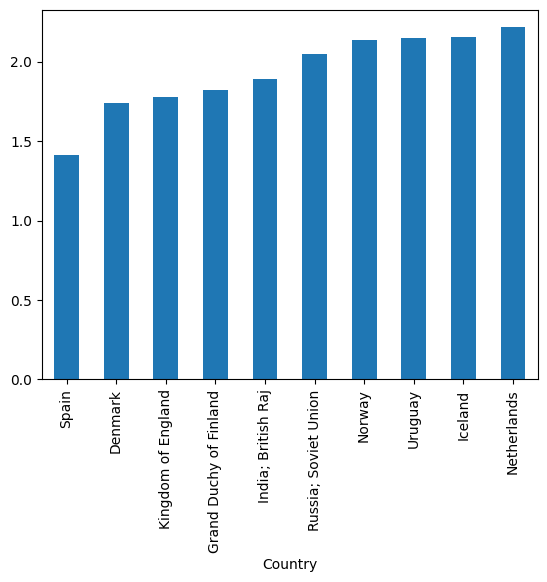

In [36]:
suicide_sorted.head(10)["suicide_per_1k"].plot(kind="bar")

<Axes: xlabel='Country'>

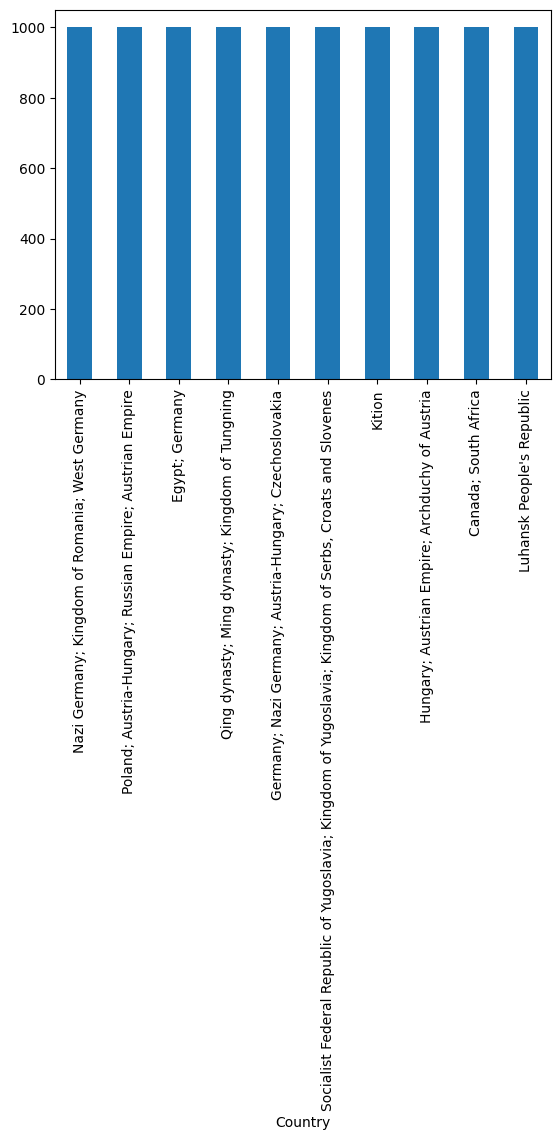

In [37]:
suicide_sorted.tail(10)["suicide_per_1k"].plot(kind="bar")

In [38]:
suicide_sorted.tail(10)

,count_suicide,count_overall,suicide_over_total,suicide_per_1k
Country,,,,
Nazi Germany; Kingdom of Romania; West Germany,1,1,1.0,1000.0
Poland; Austria-Hungary; Russian Empire; Austrian Empire,1,1,1.0,1000.0
Egypt; Germany,1,1,1.0,1000.0
Qing dynasty; Ming dynasty; Kingdom of Tungning,1,1,1.0,1000.0
Germany; Nazi Germany; Austria-Hungary; Czechoslovakia,1,1,1.0,1000.0
"Socialist Federal Republic of Yugoslavia; Kingdom of Yugoslavia; Kingdom of Serbs, Croats and Slovenes",1,1,1.0,1000.0
Kition,1,1,1.0,1000.0
Hungary; Austrian Empire; Archduchy of Austria,1,1,1.0,1000.0
Canada; South Africa,1,1,1.0,1000.0


<Axes: xlabel='Country'>

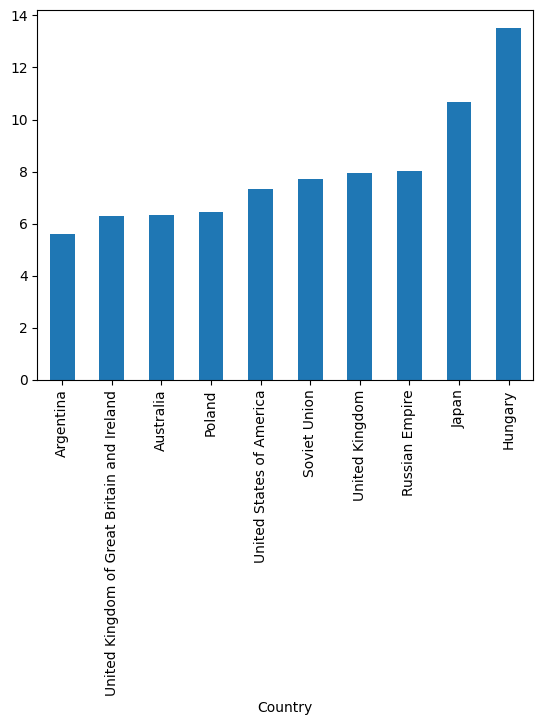

In [39]:
suicide_sorted[suicide_sorted["count_overall"] > 5000]["suicide_per_1k"].tail(10).plot(kind="bar")

In [40]:
df.isna().sum()

Id                        0
Name                      0
Short description      8428
Gender                87739
Country              182612
Occupation                0
Birth year                0
Death year                0
Manner of death      882620
Age of death              0
dtype: int64

Gender

In [41]:
df["Gender"].value_counts()

Gender
Male                                              763663
Female                                             75645
Transgender Female                                    47
Transgender Male                                      24
Eunuch; Male                                          16
Female; Male                                           6
Intersex                                               5
Transgender Male; Female                               3
Non-Binary                                             2
Transgender Person; Intersex; Transgender Male         1
Intersex; Male                                         1
Transgender Female; Female                             1
Transgender Female; Male                               1
Intersex; Transgender Male                             1
Transgender Male; Male                                 1
Female; Female                                         1
Name: count, dtype: int64

In [42]:
df.query("Gender == 'Non-Binary'")

,Id,Name,Short description,Gender,Country,Occupation,Birth year,Death year,Manner of death,Age of death
39998,Q219634,Claude Cahun,French artist (1894-1954),Non-Binary,France,Artist,1894,1954.0,NaN,60.0
754386,Q13562059,Maxine Feldman,lesbian and non-binary musician,Non-Binary,United States of America,Artist,1945,2007.0,NaN,62.0


In [43]:
df = df[df["Gender"].isin(["Male", "Female"])]

In [44]:
df_research = df[df["Occupation"] == "Researcher"]

In [45]:
df_research.shape[0]

81735

In [46]:
df_research.value_counts("Gender").loc["Male"] / len(df_research)

np.float64(0.9204624701780143)

In [47]:
df_research.value_counts("Gender", normalize=True).loc["Male"]

np.float64(0.9204624701780143)

In [48]:
def get_male_percentage(series):
    return series.value_counts(normalize=True).loc["Male"] * 100

In [49]:
get_male_percentage(df_research["Gender"])

np.float64(92.04624701780143)

In [50]:
for m in df["Occupation"].unique():
    df_filter = df[df["Occupation"] == m]
    print(m, get_male_percentage(df_filter["Gender"]))

Politician 95.615543912458
Artist 82.1756963672281
Astronomer 91.73256649892164
Athlete 96.72833532213964
Researcher 92.04624701780143
Military personnel 98.30178291619023
Philosopher 94.50272765421738
Businessperson 95.15949663447468
Explorer 97.03315881326353
Architect 96.70399592771697
Teacher 86.32561613144138
Aristocrat 62.48584371460929
Entrepreneur 96.6349670811997
Journalist 88.01171679645638
Engineer 98.81951949455483
Author 87.42255266418834
Religious figure 97.43905658716888
Official 98.76957494407159
Judge 97.11538461538461
Librarian 78.17745803357315
Translator 79.56669498725574
Physician 91.99198326943186
Inventor 97.27497935590421
Trade unionist 87.5598086124402
Merchant 98.45261121856866
Publisher 95.34782608695652
Pastor 99.01071723000825
Fencer 87.58865248226951
Rabbi 99.20704845814979
Psychologist 79.16018662519441
Lawyer 93.98694841516469
Rower 98.45460399227302
Jurist 98.8530990727184
Police officer 95.82909460834182
Surgeon 98.24890556597875
Psychiatrist 91.073038

In [51]:
gender_occup = df.groupby("Occupation")["Gender"].apply(get_male_percentage).sort_values()
gender_occup

Occupation
Novelist              59.512938
Aristocrat            62.485844
Pianist               65.903710
Librarian             78.177458
Psychologist          79.160187
Translator            79.566695
Artist                82.175696
Teacher               86.325616
Author                87.422553
Trade unionist        87.559809
Fencer                87.588652
Journalist            88.011717
Psychiatrist          91.073039
Astronomer            91.732566
Physician             91.991983
Researcher            92.046247
Lawyer                93.986948
Philosopher           94.502728
Businessperson        95.159497
Farmer                95.341098
Publisher             95.347826
Politician            95.615544
Police officer        95.829095
Entrepreneur          96.634967
Architect             96.703996
Athlete               96.728335
Explorer              97.033159
Judge                 97.115385
Minister              97.129187
Inventor              97.274979
Religious figure      97.4390

<Axes: xlabel='Occupation'>

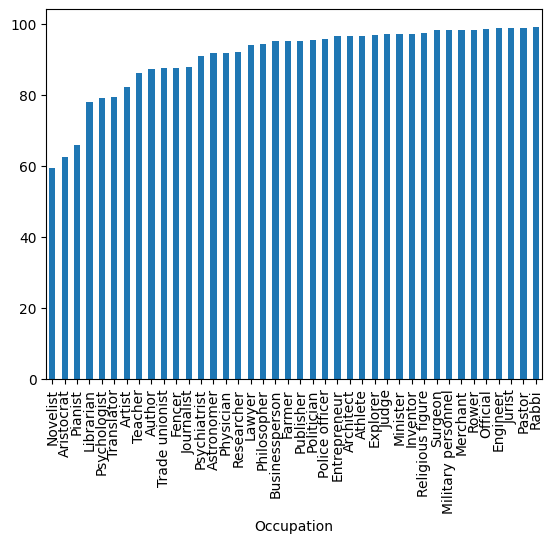

In [52]:
gender_occup.plot(kind="bar")

In [53]:
gender_occup_df = gender_occup.to_frame()
gender_occup_df.rename(columns={"Gender": "Percentage Male"}, inplace=True)

<Axes: xlabel='Occupation'>

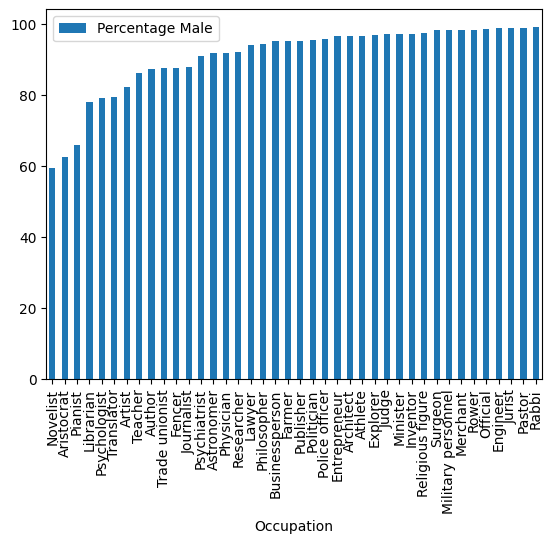

In [54]:
gender_occup_df.plot(kind="bar")

In [55]:
df_suicide

,Id,Name,Short description,Gender,Country,Occupation,Birth year,Death year,Manner of death,Age of death
23,Q440,Salvador Allende,28th president of Chile (1908–1973),Male,Chile,Politician,1908,1973.0,suicide,65.0
131,Q1322,José Manuel Balmaceda,Chilean politician and President (1840-1891),Male,Chile,Politician,1840,1891.0,suicide,51.0
189,Q2022,Cesare Pavese,"Italian poet, novelist, literary critic, and t...",Male,Italy; Kingdom of Italy,Researcher,1908,1950.0,suicide,42.0
323,Q4616,Marilyn Monroe,"American actress, model, and singer (1926-1962)",Female,United States of America,Artist,1926,1962.0,suicide,36.0
327,Q4673,Paul Otto,German film actor and director,Male,Nazi Germany; Weimar Republic; German Empire,Artist,1878,1943.0,suicide,65.0
...,...,...,...,...,...,...,...,...,...,...
1212054,Q70834687,Karl Neumann,politician and director of the Deutsche Zeiche...,NaN,German Reich,Politician,1900,1945.0,suicide,45.0
1213739,Q73375287,Peter Kuranda,Austrian journalist,Male,Austria; Austria-Hungary,Journalist,1896,1938.0,suicide,42.0
1214539,Q75135015,Michael Benveniste,American pornographic film director,Male,United States of America,Artist,1946,1982.0,suicide,36.0
1215398,Q75336010,George Dewey Sanford Jr.,United States Marine,Male,United States of America,Military personnel,1925,1994.0,suicide,69.0


In [56]:
df_suicide.Gender.value_counts(normalize=True)

Gender
Male                  0.865747
Female                0.132874
Transgender Female    0.000690
Eunuch; Male          0.000230
Transgender Male      0.000230
Intersex              0.000230
Name: proportion, dtype: float64

In [57]:
t1 = "i am from Armenia"

options = ["armenia", "armenian"]

# contained = []
# for i in options:
#     contained.append(i in t1)

contained = [i.lower() in t1.lower() for i in options]
print(any(contained))

True


In [58]:
def is_armenian(text):
    keywords = ["armenian", "armenia"]
    return (any([k in text.lower() for k in keywords]))

In [59]:
df["Armenian"] = df["Short description"].apply(is_armenian)
df

AttributeError: 'float' object has no attribute 'lower'

In [61]:
df[df["Short description"].isna()].fillna("")

,Id,Name,Short description,Gender,Country,Occupation,Birth year,Death year,Manner of death,Age of death
46515,Q287430,Pietro Guido II Torelli,,Male,,Aristocrat,1450,1494.0,,44.0
71941,Q482302,József Adamovich,,Male,,Religious figure,1845,1887.0,,42.0
75497,Q516682,István Agh,,Male,,Religious figure,1709,1786.0,,77.0
88055,Q621272,Dénes Alesius,,Male,,Religious figure,1525,1577.0,,52.0
92789,Q689315,Mátyás Ambrózy,,Male,,Pastor,1797,1869.0,,72.0
...,...,...,...,...,...,...,...,...,...,...
1219020,Q75881383,Virginia Downing,,Female,,Artist,1904,1996.0,,92.0
1219990,Q76009843,Edward Hunter Ludlow,,Male,,Physician,1810,1884.0,,74.0
1222371,Q76328370,James Gordon Dennis,,Male,,Military personnel,1921,1944.0,,23.0
1222650,Q76375951,John Calvin MacKay,,Male,,Religious figure,1891,1986.0,,95.0


In [67]:
df[df["Country"] == "Armenia"]

,Id,Name,Short description,Gender,Country,Occupation,Birth year,Death year,Manner of death,Age of death
43970,Q266968,Gurgen Margaryan,Armenian soldier,Male,Armenia,Military personnel,1978,2004.0,homicide,26.0
45653,Q278864,Andranik Ozanian,Armenian politician and military personnel (18...,Male,Armenia,Politician,1865,1927.0,NaN,62.0
54084,Q336104,Jerry Tarkanian,American basketball coach,Male,Armenia,Athlete,1930,2015.0,NaN,85.0
71000,Q471374,Karen Asrian,Armenian chess player,Male,Armenia,Athlete,1980,2008.0,natural causes,28.0
79459,Q544093,Genrikh Kasparyan,Armenian chess player,Male,Armenia,Athlete,1910,1995.0,NaN,85.0
...,...,...,...,...,...,...,...,...,...,...
1003702,Q24048886,Robert Abajyan,"Armenian military person, Hero of Artsakh",Male,Armenia,Military personnel,1996,2016.0,suicide,20.0
1025037,Q27349753,Artur Sargsyan,Armenian sculptor,Male,Armenia,Artist,1968,2017.0,NaN,49.0
1034887,Q28114502,Emma Khanzadyan,"Armenian historian, archaeologist",Female,Armenia,Researcher,1922,2007.0,NaN,85.0
1046490,Q29033966,Eduard Edigaryan,Armenian painter,Male,Armenia,Artist,1943,2019.0,NaN,76.0


In [72]:
text_based_filter = df["Short description"].fillna("na").apply(is_armenian)
country_based_filter = df["Country"].fillna("na").str.contains("Armenia")

df[(~country_based_filter) & (text_based_filter)]

,Id,Name,Short description,Gender,Country,Occupation,Birth year,Death year,Manner of death,Age of death
311,Q4452,Thomas of Metsoph,Armenian cleric and chronicler,Male,NaN,Researcher,1378,1446.0,NaN,68.0
3462,Q51472,Rouben Mamoulian,Armenian American film and theatre director,Male,United States of America; Russian Empire,Artist,1897,1987.0,NaN,90.0
3807,Q55394,Henri Verneuil,French-Armenian playwright and filmmaker,Male,France,Artist,1920,2002.0,NaN,82.0
28166,Q115683,Michael Arlen,Armenian writer,Male,NaN,Artist,1895,1956.0,natural causes,61.0
32775,Q139636,Zaven Biberyan,Armenian writer,Male,NaN,Artist,1921,1984.0,NaN,63.0
...,...,...,...,...,...,...,...,...,...,...
1118595,Q55627228,Arthur Beylerian,Armenian historian,Male,NaN,Artist,1925,2005.0,NaN,80.0
1154710,Q56650119,Gregory Casparian,"Turkish-Armenia-born painter, photo-engraver a...",Male,Turkey,Artist,1856,1942.0,NaN,86.0
1158947,Q58030786,Marie Balian,Armenian ceramic artist,Female,Israel,Artist,1925,2017.0,NaN,92.0
1166304,Q59657412,Giuseppe Arachial,Armenian Catholic bishop of Angora,Male,Ottoman Empire,Religious figure,1811,1876.0,NaN,65.0
